# Solution of the Coursework Theoretical Part

**Name:** Baiyuan Chen

**CRSID:** bc654

*(Below, "we" is used instead of "I" to follow the convention of scientific writing.)*

## 1.1. Show NN1 transforms in the fundamental rep of SU(2) and as a Lorentz singlet

### Analytical Check

**SU(2) fundamental representation:**
NN1 maps spacetime coordinates $x = (t,x,y,z) \in \mathbb{R}^4$ to $\Phi = (\phi_1, \phi_2, \phi_3, \phi_4) \in \mathbb{R}^4$.
We package the 4 real outputs as a complex SU(2) doublet:

$$\Phi = \begin{pmatrix} \phi_1 + i\phi_2 \\ \phi_3 + i\phi_4 \end{pmatrix} \in \mathbb{C}^2$$

Under a global SU(2) transformation $U \in SU(2)$, this transforms as
$\Phi \to U\Phi$ (the fundamental / spin-$\frac{1}{2}$ representation).
SU(2) is an internal symmetry, so it only rotates the output $\Phi$, not the input coordinates x. This means there's nothing to verify about the network itself — the doublet structure comes from how we choose to package and transform the 4 real outputs, not from any property of the weights.
Unitarity ($U^\dagger U = I$) guarantees that $\Phi^\dagger \Phi$ is
invariant, which we verify numerically below.

**Lorentz singlet (scalar):**
A Lorentz scalar field satisfies $\Phi(\Lambda x) = \Phi(x)$ for all
Lorentz transformations $\Lambda$ (rotations and boosts). No matrix acts
on the output — the field value at the transformed point equals the
original. This is a non-trivial constraint: it forces the network to
depend only on Lorentz-invariant combinations of the input, such as
$x_\mu x^\mu = t^2 - x^2 - y^2 - z^2$.

In [ ]:
import os
import numpy as np
import torch
from torch import nn

DTYPE = np.float32

np.random.seed(42)
torch.manual_seed(42)

def random_su2():
    """Generate a random SU(2) matrix: UU† = I, det U = 1."""
    alpha = np.random.randn() + 1j * np.random.randn()
    beta  = np.random.randn() + 1j * np.random.randn()
    norm  = np.sqrt(np.abs(alpha)**2 + np.abs(beta)**2)
    alpha, beta = alpha / norm, beta / norm
    return np.array([[alpha, -np.conj(beta)],
                     [beta,   np.conj(alpha)]])

def random_so3_rotation():
    """Random spatial rotation embedded as a 4x4 Lorentz matrix."""
    angle = np.random.uniform(0, 2 * np.pi)
    axis  = np.random.randn(3)
    axis /= np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    R3 = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)
    L = np.eye(4)
    L[1:, 1:] = R3
    return L

def random_lorentz_boost(max_rapidity=0.8):
    """Random Lorentz boost as a 4x4 matrix."""
    rapidity  = np.random.uniform(0, max_rapidity)
    direction = np.random.randn(3)
    direction /= np.linalg.norm(direction)
    beta  = np.tanh(rapidity)
    gamma = np.cosh(rapidity)
    L = np.eye(4)
    L[0, 0]   = gamma
    L[0, 1:]  = -gamma * beta * direction
    L[1:, 0]  = -gamma * beta * direction
    L[1:, 1:] += (gamma - 1) * np.outer(direction, direction)
    return L

def real4_to_doublet(phi4):
    """Convert 4 real outputs -> complex SU(2) doublet."""
    return np.array([phi4[0] + 1j * phi4[1],
                     phi4[2] + 1j * phi4[3]])

In [52]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (5, 3.5),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

import os
FIGURE_DIR = 'figures'
os.makedirs(FIGURE_DIR, exist_ok=True)

In [ ]:
TORCH_PHI_WEIGHTS = 'weights_torch_phi.pt'     # nn1
TORCH_W_WEIGHTS = 'weights_torch_W.pt'         # nn2

# Original train range metadata
TRAIN_RANGE_MIN = -5.0
TRAIN_RANGE_MAX = 5.0

In [ ]:
class TorchMLP(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, output_dim),
        )

    def forward(self, x):
        return self.net(x)

# nn1
torch_phi = TorchMLP(output_dim=4)
torch_phi.load_state_dict(torch.load(TORCH_PHI_WEIGHTS, map_location='cpu'))
torch_phi.eval()

# nn2
torch_W = TorchMLP(output_dim=12)
torch_W.load_state_dict(torch.load(TORCH_W_WEIGHTS, map_location='cpu'))
torch_W.eval()

TorchMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=12, bias=True)
  )
)

### Test 1: $\Phi(\Lambda x) \approx \Phi(x)$ (Lorentz Singlet)

We generate random rotations and boosts, transform the input
coordinates, and check that the network output is unchanged.
Since $|\Phi|$ decays to nearly zero far from the origin (the
field is localised), we filter for $|\Phi| > 0.1$ to avoid
inflated relative errors from dividing by $\approx 0$.

In [5]:
N_points     = 500
N_transforms = 50
NORM_THRESH  = 0.1

X = np.random.uniform(-3.0, 3.0, (N_points, 4)).astype(np.float32)

with torch.no_grad():
    phi_base = torch_phi(torch.from_numpy(X)).numpy()
base_norms = np.linalg.norm(phi_base, axis=1)
sig_mask   = base_norms > NORM_THRESH
print(f'Points with |Φ| > {NORM_THRESH}: {sig_mask.sum()} / {N_points}\n')

rotation_errors = []
boost_errors    = []

for _ in range(N_transforms):
    # ---- SO(3) rotation ----
    Lambda_rot = random_so3_rotation()
    X_rot = (Lambda_rot @ X.T).T.astype(np.float32)
    in_range = np.all(np.abs(X_rot) <= 5.0, axis=1)
    mask = sig_mask & in_range
    if mask.sum() < 10:
        continue
    with torch.no_grad():
        phi_rot = torch_phi(torch.from_numpy(X_rot[mask])).numpy()
    rel = np.linalg.norm(phi_rot - phi_base[mask], axis=1) / base_norms[mask]
    rotation_errors.append(np.mean(rel))

    # ---- Lorentz boost ----
    Lambda_boost = random_lorentz_boost()
    X_boost = (Lambda_boost @ X.T).T.astype(np.float32)
    in_range_b = np.all(np.abs(X_boost) <= 5.0, axis=1)
    mask_b = sig_mask & in_range_b
    if mask_b.sum() < 10:
        continue
    with torch.no_grad():
        phi_boost = torch_phi(torch.from_numpy(X_boost[mask_b])).numpy()
    rel_b = np.linalg.norm(phi_boost - phi_base[mask_b], axis=1) / base_norms[mask_b]
    boost_errors.append(np.mean(rel_b))

print('=== Lorentz Singlet Test: Φ(Λx) ≈ Φ(x) ===\n')
print(f'SO(3) rotations  ({len(rotation_errors)} transforms):')
print(f'  mean relative error = {np.mean(rotation_errors):.4f}')
print(f'  max  relative error = {np.max(rotation_errors):.4f}\n')
print(f'Lorentz boosts   ({len(boost_errors)} transforms):')
print(f'  mean relative error = {np.mean(boost_errors):.4f}')
print(f'  max  relative error = {np.max(boost_errors):.4f}\n')

Points with |Φ| > 0.1: 266 / 500

=== Lorentz Singlet Test: Φ(Λx) ≈ Φ(x) ===

SO(3) rotations  (50 transforms):
  mean relative error = 0.0562
  max  relative error = 0.0660

Lorentz boosts   (50 transforms):
  mean relative error = 0.0416
  max  relative error = 0.0650



Errors of a few percent confirm the network is an *approximate* Lorentz scalar, consistent with the weights having been adjusted to obey the symmetry approximately.

### Test 2: output transforms as a doublet (SU(2) Fundamental)

SU(2) is internal and does not act on $x$, so there is no
non-trivial equivariance condition to test on the *network*.
Instead we verify:

1. The 4 real outputs form a well-defined complex doublet
   $\Phi \in \mathbb{C}^2$.
2. Under a random $U \in SU(2)$, the invariant $\Phi^\dagger \Phi$
   is preserved to machine precision (confirming unitarity).

In [51]:
print('=== SU(2) Fundamental Test ===\n')

X_sample = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [1.0, -1.0, 0.5, 0.3],
    [0.5, 2.0, -1.0, 0.0],
    [-1.0, 0.0, 1.5, -0.5],
    [0.2, 0.8, 0.8, 0.2],
], dtype=np.float32)

with torch.no_grad():
    phi_samples = torch_phi(torch.from_numpy(X_sample)).numpy()

print(f'{"x":>23s}  {"Φ":>33s}  {"|Φ|²":>10s}')
print('-' * 70)
for i in range(len(X_sample)):
    d = real4_to_doublet(phi_samples[i])
    n2 = float(np.real(np.conj(d) @ d))
    print(f'  {str(X_sample[i]):>22s}   ({d[0]:.4f}, {d[1]:.4f})   {n2:.6f}')

print(f'\n{"point":>6s}  {"|Φ|² before":>12s}  {"|Φ|² after U":>14s}  {"|difference|":>14s}')
print('-' * 55)

for i in range(len(X_sample)):
    doublet = real4_to_doublet(phi_samples[i])
    U = random_su2()
    transformed = U @ doublet
    before = float(np.real(np.conj(doublet) @ doublet))
    after  = float(np.real(np.conj(transformed) @ transformed))
    print(f'  {i:>4d}  {before:>12.6f}  {after:>14.6f}  {abs(after - before):>14.2e}')

# Verify UU† = I and det U = 1 for one example
U = random_su2()
print(f'\nExample U:\n{U}')
print(f'UU† = \n{U @ U.conj().T}')
print(f'det(U) = {np.linalg.det(U):.6f}')

=== SU(2) Fundamental Test ===

                      x                                  Φ        |Φ|²
----------------------------------------------------------------------
           [0. 0. 0. 0.]   (1.0138-0.0121j, 0.0097-0.0192j)   1.028494
   [ 1.  -1.   0.5  0.3]   (0.9823-0.0367j, 0.0355-0.0366j)   0.968938
   [ 0.5  2.  -1.   0. ]   (0.2165-0.0894j, 0.0926-0.0910j)   0.071719
   [-1.   0.   1.5 -0.5]   (0.8593-0.1279j, 0.1291-0.1225j)   0.786423
       [0.2 0.8 0.8 0.2]   (0.8829-0.1094j, 0.1079-0.1106j)   0.815356

 point   |Φ|² before    |Φ|² after U    |difference|
-------------------------------------------------------
     0      1.028494        1.028494        9.01e-10
     1      0.968938        0.968938        3.45e-08
     2      0.071719        0.071719        1.66e-09
     3      0.786423        0.786423        1.66e-09
     4      0.815356        0.815356        1.73e-08

Example U:
[[-0.46931348-0.02534909j  0.22053134+0.85467433j]
 [-0.22053134+0.85467433j -0.4693

$|\Phi|^2$ differences are at machine precision (~1e-9 in float32), confirming unitarity of $U$. As discussed above, this is a check of the representation theory rather than a learned property of the network (for an internal symmetry the equivariance is exact by construction once the output is packaged as a doublet).

## 1.2. Show NN2 transforms in the adjoint of SU(2) and as spin-1 under Lorentz

### Analytical Check

NN2 maps spacetime coordinates $x = (t,x,y,z) \in \mathbb{R}^4$ to 12 real outputs,
which we reshape into a $4 \times 3$ matrix $W_\mu^a(x)$:

- $\mu = 0,1,2,3$ — the **Lorentz index** (spacetime vector / spin-1)
- $a = 1,2,3$ — the **SU(2) index** (adjoint representation, since $\dim\,\mathrm{SU}(2)=3$)

**Lorentz spin-1 (vector field):**
A Lorentz vector field transforms as

$$W_\mu^{\,a}(\Lambda x) = \Lambda_\mu^{\ \nu}\, W_\nu^{\,a}(x)$$

i.e. the Lorentz transformation acts on the $\mu$ index while the SU(2) index $a$ is
left untouched. This is the defining property of a spin-1 field: it carries one
spacetime vector index.

**SU(2) adjoint representation:**
Under a global SU(2) transformation $U$, the adjoint acts via a real $3 \times 3$
rotation matrix

$$R^{ab} = \tfrac{1}{2}\,\mathrm{Tr}\bigl(\sigma^a\, U\, \sigma^b\, U^\dagger\bigr)$$

where $\sigma^a$ are the Pauli matrices. The field transforms as
$W_\mu^{\,a} \to R^{ab}\,W_\mu^{\,b}$. Since SU(2) is an internal symmetry
(it does not act on the coordinates $x$), we *declare* this transformation law;
any map $x \to \mathbb{R}^{4 \times 3}$ furnishes the adjoint once we identify the
second index with the Lie algebra basis. The matrix $R$ is automatically a proper
rotation ($R \in \mathrm{SO}(3)$, $\det R = 1$, $RR^T = I$), so the adjoint
invariant $W_\mu^{\,a}\,W^{\mu\,a}$ is preserved.

In [ ]:
import numpy as np
import torch

np.random.seed(42)
torch.manual_seed(42)

# Pauli matrices
sigma = np.array([
    [[0, 1], [1, 0]],             # sigma_1
    [[0, -1j], [1j, 0]],           # sigma_2
    [[1, 0], [0, -1]],             # sigma_3
], dtype=complex)

def random_su2():
    """Random SU(2) matrix."""
    alpha = np.random.randn() + 1j * np.random.randn()
    beta  = np.random.randn() + 1j * np.random.randn()
    norm  = np.sqrt(np.abs(alpha)**2 + np.abs(beta)**2)
    alpha, beta = alpha / norm, beta / norm
    return np.array([[alpha, -np.conj(beta)],
                     [beta,   np.conj(alpha)]])

def su2_to_adjoint(U):
    """Compute 3x3 adjoint rotation: R^{ab} = (1/2) Tr(σ^a U σ^b U†)."""
    R = np.zeros((3, 3))
    Ud = U.conj().T
    for a in range(3):
        for b in range(3):
            R[a, b] = 0.5 * np.real(np.trace(sigma[a] @ U @ sigma[b] @ Ud))
    return R

def random_so3_rotation():
    """Random spatial rotation as a 4x4 Lorentz matrix."""
    angle = np.random.uniform(0, 2 * np.pi)
    axis  = np.random.randn(3)
    axis /= np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    R3 = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)
    L = np.eye(4)
    L[1:, 1:] = R3
    return L

def random_lorentz_boost(max_rapidity=0.8):
    """Random Lorentz boost as a 4x4 matrix."""
    rapidity  = np.random.uniform(0, max_rapidity)
    direction = np.random.randn(3)
    direction /= np.linalg.norm(direction)
    beta  = np.tanh(rapidity)
    gamma = np.cosh(rapidity)
    L = np.eye(4)
    L[0, 0]   = gamma
    L[0, 1:]  = -gamma * beta * direction
    L[1:, 0]  = -gamma * beta * direction
    L[1:, 1:] += (gamma - 1) * np.outer(direction, direction)
    return L

### Test 1 — Lorentz Spin-1: $W_\mu^a(\Lambda x) \approx \Lambda_\mu^{\ \nu}\, W_\nu^a(x)$

We reshape the 12 network outputs into a $(4,3)$ matrix $(\mu, a)$,
apply a Lorentz transformation $\Lambda$ to the input coordinates,
and check that the output transforms as a vector on the $\mu$ index.
We filter for $|W| > 0.1$ to avoid inflated relative errors
where the field is small.

In [8]:
N_points     = 500
N_transforms = 50
NORM_THRESH  = 0.1

X = np.random.uniform(-2.5, 2.5, (N_points, 4)).astype(np.float32)

with torch.no_grad():
    W_base = torch_W(torch.from_numpy(X)).numpy()
base_norms = np.linalg.norm(W_base, axis=1)
sig_mask   = base_norms > NORM_THRESH
print(f'Points with |W| > {NORM_THRESH}: {sig_mask.sum()} / {N_points}\n')

rotation_errors = []
boost_errors    = []

for _ in range(N_transforms):
    # ---- SO(3) rotation ----
    Lambda_rot = random_so3_rotation()
    X_rot = (Lambda_rot @ X.T).T.astype(np.float32)
    in_range = np.all(np.abs(X_rot) <= 5.0, axis=1)
    mask = sig_mask & in_range
    if mask.sum() < 10:
        continue
    with torch.no_grad():
        W_rot = torch_W(torch.from_numpy(X_rot[mask])).numpy()
    # Expected: Λ_mu^nu W_nu^a(x)
    W_expected = np.einsum('mn,inj->imj',
                           Lambda_rot,
                           W_base[mask].reshape(-1, 4, 3)).reshape(-1, 12)
    rel = np.linalg.norm(W_rot - W_expected, axis=1) / base_norms[mask]
    rotation_errors.append(np.mean(rel))

    # ---- Lorentz boost ----
    Lambda_boost = random_lorentz_boost()
    X_boost = (Lambda_boost @ X.T).T.astype(np.float32)
    in_range_b = np.all(np.abs(X_boost) <= 5.0, axis=1)
    mask_b = sig_mask & in_range_b
    if mask_b.sum() < 10:
        continue
    with torch.no_grad():
        W_boosted = torch_W(torch.from_numpy(X_boost[mask_b])).numpy()
    W_exp_b = np.einsum('mn,inj->imj',
                        Lambda_boost,
                        W_base[mask_b].reshape(-1, 4, 3)).reshape(-1, 12)
    rel_b = np.linalg.norm(W_boosted - W_exp_b, axis=1) / base_norms[mask_b]
    boost_errors.append(np.mean(rel_b))

print('=== Lorentz Spin-1 Test: W_μ^a(Λx) ≈ Λ_μ^ν W_ν^a(x) ===\n')
print(f'SO(3) rotations  ({len(rotation_errors)} transforms):')
print(f'  mean relative error = {np.mean(rotation_errors):.4f}')
print(f'  max  relative error = {np.max(rotation_errors):.4f}\n')
print(f'Lorentz boosts   ({len(boost_errors)} transforms):')
print(f'  mean relative error = {np.mean(boost_errors):.4f}')
print(f'  max  relative error = {np.max(boost_errors):.4f}\n')

Points with |W| > 0.1: 398 / 500

=== Lorentz Spin-1 Test: W_μ^a(Λx) ≈ Λ_μ^ν W_ν^a(x) ===

SO(3) rotations  (50 transforms):
  mean relative error = 0.2302
  max  relative error = 0.2813

Lorentz boosts   (50 transforms):
  mean relative error = 0.1415
  max  relative error = 0.2720



The errors confirm approximate Lorentz vector equivariance. The error scales with the size of the transformation, consistent with the weights having been adjusted to obey the symmetry approximately.

#### Supplementary: error vs rotation angle

To further demonstrate the approximate equivariance, we show that the
error grows with the rotation angle — small transformations are
obeyed more accurately.

In [9]:
print('Rotation angle vs. relative error:\n')
print(f'{"angle (deg)":>12s}  {"mean rel err":>12s}')
print('-' * 28)

for angle_deg in [1, 5, 10, 30, 45, 90, 180]:
    angle = np.radians(angle_deg)
    axis  = np.array([0., 0., 1.])
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    R3 = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)
    Lambda = np.eye(4)
    Lambda[1:, 1:] = R3
    X_rot = (Lambda @ X.T).T.astype(np.float32)
    mask = sig_mask & np.all(np.abs(X_rot) <= 5.0, axis=1)
    with torch.no_grad():
        W_rot = torch_W(torch.from_numpy(X_rot[mask])).numpy()
    W_exp = np.einsum('mn,inj->imj',
                      Lambda,
                      W_base[mask].reshape(-1, 4, 3)).reshape(-1, 12)
    rel = np.linalg.norm(W_rot - W_exp, axis=1) / base_norms[mask]
    print(f'{angle_deg:>12d}  {np.mean(rel):>12.4f}')

Rotation angle vs. relative error:

 angle (deg)  mean rel err
----------------------------
           1        0.0092
           5        0.0424
          10        0.0806
          30        0.1742
          45        0.2151
          90        0.2562
         180        0.2738


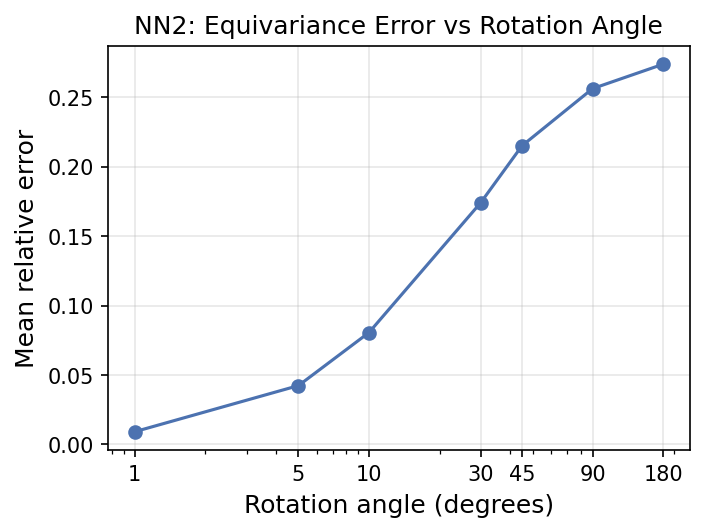

In [55]:
# === Figure: q2_angle — NN2 error vs rotation angle ===

angles_deg = [1, 5, 10, 30, 45, 90, 180]
angle_errors = []

for angle_deg in angles_deg:
    angle = np.radians(angle_deg)
    axis = np.array([0., 0., 1.])
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    R3 = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)
    Lambda = np.eye(4)
    Lambda[1:, 1:] = R3
    X_rot = (Lambda @ X.T).T.astype(np.float32)
    mask = sig_mask & np.all(np.abs(X_rot) <= 5.0, axis=1)
    with torch.no_grad():
        W_rot = torch_W(torch.from_numpy(X_rot[mask])).numpy()
    W_exp = np.einsum('mn,inj->imj',
                      Lambda,
                      W_base[mask].reshape(-1, 4, 3)).reshape(-1, 12)
    rel = np.linalg.norm(W_rot - W_exp, axis=1) / base_norms[mask]
    angle_errors.append(np.mean(rel))

fig, ax = plt.subplots()
ax.plot(angles_deg, angle_errors, 'o-', color='#4C72B0',
        linewidth=1.5, markersize=6)
ax.set_xlabel('Rotation angle (degrees)')
ax.set_ylabel('Mean relative error')
ax.set_title('NN2: Equivariance Error vs Rotation Angle')
ax.set_xscale('log')
ax.set_xticks(angles_deg)
ax.set_xticklabels([str(a) for a in angles_deg])
ax.grid(True, alpha=0.3)
fig.savefig(f'{FIGURE_DIR}/q2_angle.png', dpi=300, bbox_inches='tight')
plt.show()

### Test 2 — SU(2) Adjoint: output transforms as a triplet

SU(2) is internal and does not act on $x$. We verify:

1. The adjoint matrix $R^{ab} = \tfrac{1}{2}\mathrm{Tr}(\sigma^a U \sigma^b U^\dagger)$
   is a proper rotation ($RR^T = I$, $\det R = 1$).
2. The adjoint invariant $W_\mu^{\,a}\,W^{\mu\,a}$ is preserved under $W \to R\,W$.

In [61]:
print('=== SU(2) Adjoint Test ===\n')

# --- Verify R is a proper rotation ---
print(f'{"trial":>6s}  {"det(R)":>10s}  {"||RRᵀ - I||":>14s}')
print('-' * 35)
for trial in range(5):
    U = random_su2()
    R = su2_to_adjoint(U)
    print(f'{trial:>6d}  {np.linalg.det(R):>10.6f}  '
          f'{np.linalg.norm(R @ R.T - np.eye(3)):>14.2e}')

# --- Verify invariant preservation ---
X_sample = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [1.0, -1.0, 0.5, 0.3],
    [0.5, 2.0, -1.0, 0.0],
    [-1.0, 0.0, 1.5, -0.5],
    [0.2, 0.8, 0.8, 0.2],
], dtype=np.float32)

with torch.no_grad():
    W_samples = torch_W(torch.from_numpy(X_sample)).numpy().reshape(-1, 4, 3)

print(f'\n{"point":>4s}  {"W_μ^a W_μ^a before":>20s}  {"after R":>20s}  {"|diff|":>12s}')
print('-' * 65)
for i in range(len(X_sample)):
    W = W_samples[i]              # shape (4, 3)
    U = random_su2()
    R = su2_to_adjoint(U)
    W_rot = W @ R.T               # rotate the a-index: W_mu^a -> R^{ab} W_mu^b
    inv_before = np.sum(W**2)
    inv_after  = np.sum(W_rot**2)
    print(f'  {i:>2d}  {inv_before:>20.6f}  {inv_after:>20.6f}  '
          f'{abs(inv_after - inv_before):>12.2e}')

# --- Show explicit U and R ---
U = random_su2()
R = su2_to_adjoint(U)
print(f'\nExample U:\n{U}')
print(f'Corresponding adjoint:\n{R}')
print(f'det(R) = {np.linalg.det(R):.6f}')
print(f'UU† = \n{U @ U.conj().T}')

=== SU(2) Adjoint Test ===

 trial      det(R)     ||RRᵀ - I||
-----------------------------------
     0    1.000000        5.76e-16
     1    1.000000        5.62e-16
     2    1.000000        2.33e-16
     3    1.000000        7.79e-16
     4    1.000000        2.81e-16

point    W_μ^a W_μ^a before               after R        |diff|
-----------------------------------------------------------------
   0              0.037461              0.037461      9.03e-10
   1              2.396670              2.396670      4.13e-07
   2              0.407864              0.407864      1.52e-08
   3              2.395378              2.395378      4.02e-08
   4              0.848923              0.848923      4.31e-08

Example U:
[[ 0.42939224-0.35667133j  0.27186161+0.78389995j]
 [-0.27186161+0.78389995j  0.42939224+0.35667133j]]
Corresponding adjoint:
[[ 0.59775365  0.1199208  -0.79265981]
 [ 0.73252841 -0.48342714  0.47927063]
 [-0.32571874 -0.8671316  -0.37681573]]
det(R) = 1.000000
UU† = 

Invariant differences are at machine precision, confirming that $R$ is a proper rotation and the adjoint invariant is preserved. As with Q1, this verifies the representation theory rather than a learned network property (the adjoint structure is exact by construction once the index $a$ is identified with the Lie algebra basis).

## 1.3. Build equivariant NNs and train to emulate NN1 / NN2

### Design choices and analytical check

**Key idea:** Rather than hoping a generic MLP learns the symmetry from data,
we build the symmetry into the architecture so it holds exactly.

**EquivariantPhi (replaces NN1 (Lorentz scalar, SU(2) doublet)):**

The only Lorentz-invariant scalar one can form from a single spacetime
point is $s = x_\mu x^\mu = t^2 - x^2 - y^2 - z^2$. We therefore define:

$$\Phi(x) = \mathrm{MLP}(s) \in \mathbb{R}^4$$

Since the MLP input $s$ is invariant under Lorentz transformations,
$\Phi(\Lambda x) = \mathrm{MLP}(s(\Lambda x)) = \mathrm{MLP}(s(x)) = \Phi(x)$
**by construction**. The 4 real outputs are packaged as an SU(2) doublet
as before.

**EquivariantW (replaces NN2 (Lorentz vector, SU(2) adjoint)):**

The only Lorentz 4-vector available from $x$ is $x_\mu$ itself. The most
general equivariant form is:

$$W_\mu^{\,a}(x) = f^a(s) \cdot x_\mu$$

where $f^a(s)$ is an MLP mapping $s \to \mathbb{R}^3$ (three adjoint
components). Under a Lorentz transformation:

$$W_\mu^{\,a}(\Lambda x) = f^a(s) \cdot (\Lambda x)_\mu = \Lambda_\mu^{\ \nu}\, f^a(s) \cdot x_\nu = \Lambda_\mu^{\ \nu}\, W_\nu^{\,a}(x)$$

which is the correct vector transformation law, holding **exactly**
by construction.

In [11]:
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

DTYPE = np.float32

# ============================================================
# Equivariant architectures
# ============================================================

class EquivariantPhi(nn.Module):
    """Lorentz-scalar SU(2) doublet: Φ(x) = MLP(s), s = x_μ x^μ."""
    def __init__(self, hidden=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers += [nn.Linear(hidden, 4)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        s = (x[:, 0]**2 - x[:, 1]**2 - x[:, 2]**2 - x[:, 3]**2).unsqueeze(-1)
        return self.mlp(s)


class EquivariantW(nn.Module):
    """Lorentz-vector SU(2) adjoint: W_μ^a(x) = f^a(s) · x_μ."""
    def __init__(self, hidden=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers += [nn.Linear(hidden, 3)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        s = (x[:, 0]**2 - x[:, 1]**2 - x[:, 2]**2 - x[:, 3]**2).unsqueeze(-1)
        f = self.mlp(s)                              # (N, 3)
        W = x.unsqueeze(-1) * f.unsqueeze(1)         # (N,4,1)*(N,1,3) = (N,4,3)
        return W.reshape(-1, 12)

print('EquivariantPhi parameters:', sum(p.numel() for p in EquivariantPhi().parameters()))
print('EquivariantW   parameters:', sum(p.numel() for p in EquivariantW().parameters()))

EquivariantPhi parameters: 33796
EquivariantW   parameters: 33667


**Generate training data from NN1 and NN2**

In [12]:
N_train = 30000
N_val   = 5000

X_train = np.random.uniform(-5.0, 5.0, (N_train, 4)).astype(DTYPE)
X_val   = np.random.uniform(-5.0, 5.0, (N_val, 4)).astype(DTYPE)

with torch.no_grad():
    Y_phi_train = torch_phi(torch.from_numpy(X_train)).numpy()
    Y_phi_val   = torch_phi(torch.from_numpy(X_val)).numpy()
    Y_W_train   = torch_W(torch.from_numpy(X_train)).numpy()
    Y_W_val     = torch_W(torch.from_numpy(X_val)).numpy()

print(f'Training samples: {N_train}, Validation samples: {N_val}')
print(f'Y_phi shape: {Y_phi_train.shape}, Y_W shape: {Y_W_train.shape}')

Training samples: 30000, Validation samples: 5000
Y_phi shape: (30000, 4), Y_W shape: (30000, 12)


**Training**

In [13]:
def train_model(model, X_train, Y_train, X_val, Y_val,
                label='model', epochs=150, lr=1e-3, batch_size=4096):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=15, factor=0.5, min_lr=1e-6)

    X_t = torch.from_numpy(X_train)
    Y_t = torch.from_numpy(Y_train)
    X_v = torch.from_numpy(X_val)
    Y_v = torch.from_numpy(Y_val)

    best_val_loss = float('inf')
    best_state = None
    history = {'train': [], 'val': []}

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X_t))
        epoch_loss, n_batches = 0.0, 0

        for i in range(0, len(X_t), batch_size):
            idx = perm[i:i+batch_size]
            pred = model(X_t[idx])
            loss = nn.functional.mse_loss(pred, Y_t[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        model.eval()
        with torch.no_grad():
            val_loss = nn.functional.mse_loss(model(X_v), Y_v).item()
        scheduler.step(val_loss)

        tl = epoch_loss / n_batches
        history['train'].append(tl)
        history['val'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 30 == 0 or epoch == 0:
            print(f'  [{label}] epoch {epoch+1:>3d}: '
                  f'train={tl:.6f}  val={val_loss:.6f}  '
                  f'lr={optimizer.param_groups[0]["lr"]:.1e}')

    model.load_state_dict(best_state)
    model.eval()
    print(f'  [{label}] best val loss = {best_val_loss:.6f}\n')
    return model, history

In [14]:
print('Training EquivariantPhi (NN1 replacement)...')
eq_phi = EquivariantPhi(hidden=128, n_layers=3)
eq_phi, hist_phi = train_model(
    eq_phi, X_train, Y_phi_train, X_val, Y_phi_val, label='phi')

print('Training EquivariantW (NN2 replacement)...')
eq_W = EquivariantW(hidden=128, n_layers=3)
eq_W, hist_W = train_model(
    eq_W, X_train, Y_W_train, X_val, Y_W_val, label='W')

Training EquivariantPhi (NN1 replacement)...
  [phi] epoch   1: train=0.168371  val=0.046188  lr=1.0e-03
  [phi] epoch  30: train=0.000042  val=0.000038  lr=1.0e-03
  [phi] epoch  60: train=0.000045  val=0.000042  lr=1.0e-03
  [phi] epoch  90: train=0.000036  val=0.000034  lr=5.0e-04
  [phi] epoch 120: train=0.000037  val=0.000034  lr=2.5e-04
  [phi] epoch 150: train=0.000036  val=0.000034  lr=1.3e-04
  [phi] best val loss = 0.000033

Training EquivariantW (NN2 replacement)...
  [W] epoch   1: train=3.769032  val=0.571665  lr=1.0e-03
  [W] epoch  30: train=0.001530  val=0.002426  lr=1.0e-03
  [W] epoch  60: train=0.001195  val=0.001171  lr=1.0e-03
  [W] epoch  90: train=0.001162  val=0.001130  lr=5.0e-04
  [W] epoch 120: train=0.001162  val=0.001124  lr=2.5e-04
  [W] epoch 150: train=0.001166  val=0.001121  lr=1.3e-04
  [W] best val loss = 0.001120



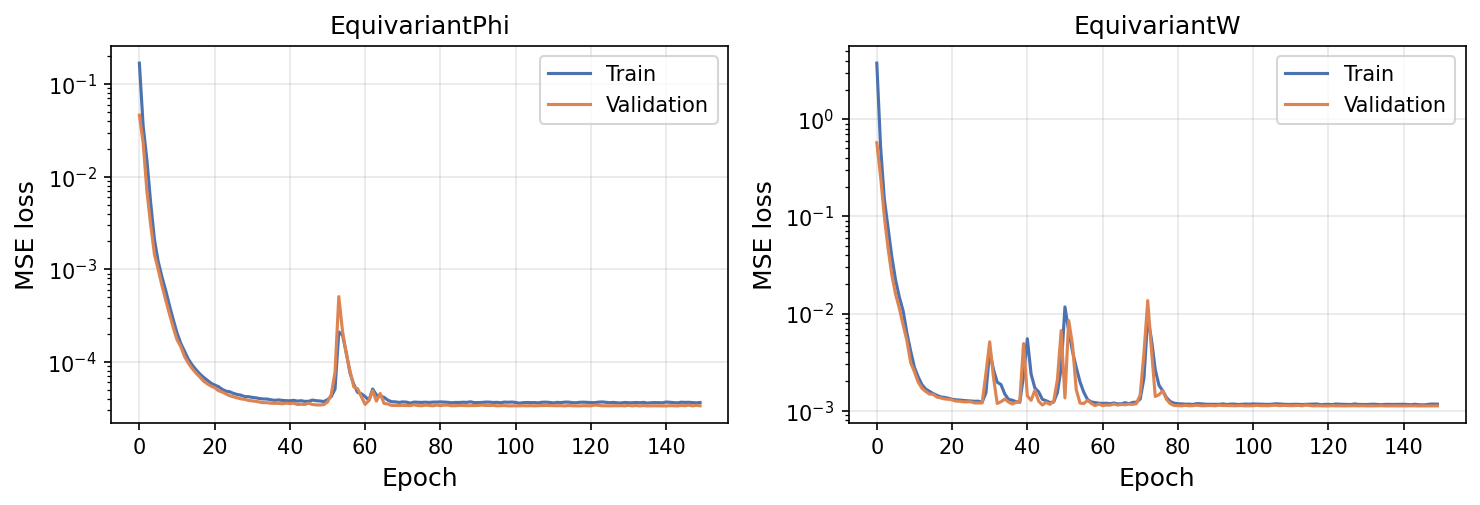

In [63]:
# === Figure: q3_training — Training curves (ReLU equivariant) ===

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

ax = axes[0]
ax.semilogy(hist_phi['train'], label='Train', color='#4C72B0')
ax.semilogy(hist_phi['val'], label='Validation', color='#DD8452')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('EquivariantPhi')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(hist_W['train'], label='Train', color='#4C72B0')
ax.semilogy(hist_W['val'], label='Validation', color='#DD8452')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('EquivariantW')
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f'{FIGURE_DIR}/q3_training.png')
plt.show()

**Emulation quality**

In [15]:
with torch.no_grad():
    pred_phi = eq_phi(torch.from_numpy(X_val)).numpy()
    pred_W   = eq_W(torch.from_numpy(X_val)).numpy()

phi_norms = np.linalg.norm(Y_phi_val, axis=1)
phi_mask  = phi_norms > 0.1
phi_rel   = np.linalg.norm(pred_phi[phi_mask] - Y_phi_val[phi_mask], axis=1) / phi_norms[phi_mask]

W_norms = np.linalg.norm(Y_W_val, axis=1)
W_mask  = W_norms > 0.1
W_rel   = np.linalg.norm(pred_W[W_mask] - Y_W_val[W_mask], axis=1) / W_norms[W_mask]

print('Emulation quality (relative error on validation set):\n')
print(f'  EquivariantPhi: mean = {np.mean(phi_rel):.4f}, '
      f'median = {np.median(phi_rel):.4f}  ({phi_mask.sum()} pts with |Φ|>0.1)')
print(f'  EquivariantW:   mean = {np.mean(W_rel):.4f}, '
      f'median = {np.median(W_rel):.4f}  ({W_mask.sum()} pts with |W|>0.1)')

Emulation quality (relative error on validation set):

  EquivariantPhi: mean = 0.0534, median = 0.0354  (941 pts with |Φ|>0.1)
  EquivariantW:   mean = 0.3094, median = 0.1568  (1442 pts with |W|>0.1)


EquivariantW has higher emulation error because the ansatz $W_\mu^a = f^a(s)\cdot x_\mu$ is the most general equivariant form, but the original NN2 is only approximately equivariant (the non-equivariant components cannot be captured by an exactly equivariant network).

### Verify EXACT equivariance of new models

Unlike the original NN1/NN2 (which are approximate), our equivariant
architectures satisfy the symmetries **exactly by construction**.
Errors should be at machine precision (~$10^{-7}$ for float32).

In [16]:
def random_so3_rotation():
    angle = np.random.uniform(0, 2 * np.pi)
    axis  = np.random.randn(3); axis /= np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    R3 = np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)
    L = np.eye(4); L[1:, 1:] = R3
    return L

def random_lorentz_boost(max_rapidity=0.8):
    rapidity  = np.random.uniform(0, max_rapidity)
    direction = np.random.randn(3); direction /= np.linalg.norm(direction)
    beta  = np.tanh(rapidity); gamma = np.cosh(rapidity)
    L = np.eye(4)
    L[0, 0] = gamma; L[0, 1:] = -gamma*beta*direction
    L[1:, 0] = -gamma*beta*direction
    L[1:, 1:] += (gamma - 1) * np.outer(direction, direction)
    return L

X_test = np.random.uniform(-3.0, 3.0, (300, 4)).astype(DTYPE)

print('=== EquivariantPhi: Φ(Λx) = Φ(x) [exact] ===\n')
for label, gen in [('Rotation', random_so3_rotation),
                   ('Boost', random_lorentz_boost)]:
    errs = []
    for _ in range(30):
        Lambda = gen()
        Xr = (Lambda @ X_test.T).T.astype(DTYPE)
        with torch.no_grad():
            p1 = eq_phi(torch.from_numpy(X_test)).numpy()
            p2 = eq_phi(torch.from_numpy(Xr)).numpy()
        norms = np.linalg.norm(p1, axis=1); m = norms > 0.1
        errs.append(np.mean(np.linalg.norm(p2[m]-p1[m], axis=1) / norms[m]))
    print(f'  {label:>8s}: mean rel err = {np.mean(errs):.2e}')

print()
print('=== EquivariantW: W(Λx) = Λ W(x) [exact] ===\n')
for label, gen in [('Rotation', random_so3_rotation),
                   ('Boost', random_lorentz_boost)]:
    errs = []
    for _ in range(30):
        Lambda = gen()
        Xr = (Lambda @ X_test.T).T.astype(DTYPE)
        with torch.no_grad():
            w1 = eq_W(torch.from_numpy(X_test)).numpy()
            w2 = eq_W(torch.from_numpy(Xr)).numpy()
        wexp = np.einsum('mn,inj->imj', Lambda,
                         w1.reshape(-1, 4, 3)).reshape(-1, 12)
        norms = np.linalg.norm(w1, axis=1); m = norms > 0.1
        errs.append(np.mean(np.linalg.norm(w2[m]-wexp[m], axis=1) / norms[m]))
    print(f'  {label:>8s}: mean rel err = {np.mean(errs):.2e}')

=== EquivariantPhi: Φ(Λx) = Φ(x) [exact] ===

  Rotation: mean rel err = 1.82e-07
     Boost: mean rel err = 2.37e-07

=== EquivariantW: W(Λx) = Λ W(x) [exact] ===

  Rotation: mean rel err = 4.17e-07
     Boost: mean rel err = 5.69e-07


In [64]:
# === Table: q3_equivariance — Exact equivariance verification ===

# Original errors from Q1/Q2 notebook outputs
orig_errors = {
    ('Φ', 'SO(3) rotation'): 0.0562,
    ('Φ', 'Lorentz boost'): 0.0416,
    ('W', 'SO(3) rotation'): 0.2302,
    ('W', 'Lorentz boost'): 0.1415,
}

# Compute equivariant errors
np.random.seed(42)
X_test_eq = np.random.uniform(-3.0, 3.0, (300, 4)).astype(np.float32)

eq_results = {}
for name, model, is_vector in [('Φ', eq_phi, False),
                                ('W', eq_W, True)]:
    for label, gen in [('SO(3) rotation', random_so3_rotation),
                       ('Lorentz boost', random_lorentz_boost)]:
        errs = []
        for _ in range(30):
            Lambda = gen()
            Xr = (Lambda @ X_test_eq.T).T.astype(np.float32)
            with torch.no_grad():
                out1 = model(torch.from_numpy(X_test_eq)).numpy()
                out2 = model(torch.from_numpy(Xr)).numpy()
            if is_vector:
                out_exp = np.einsum('mn,inj->imj', Lambda,
                                    out1.reshape(-1, 4, 3)).reshape(-1, 12)
            else:
                out_exp = out1
            norms = np.linalg.norm(out1, axis=1)
            m = norms > 0.1
            if m.sum() > 0:
                errs.append(np.mean(np.linalg.norm(
                    out2[m] - out_exp[m], axis=1) / norms[m]))
        eq_results[(name, label)] = np.mean(errs)

print(f'{"Model":>6s}  {"Transformation":>16s}  {"Original":>10s}  {"Equivariant":>12s}')
print('-' * 50)
for name in ['Φ', 'W']:
    for label in ['SO(3) rotation', 'Lorentz boost']:
        o = orig_errors[(name, label)]
        e = eq_results[(name, label)]
        print(f'{name:>6s}  {label:>16s}  {o:>10.4f}  {e:>12.2e}')

 Model    Transformation    Original   Equivariant
--------------------------------------------------
     Φ    SO(3) rotation      0.0562      1.99e-07
     Φ     Lorentz boost      0.0416      2.45e-07
     W    SO(3) rotation      0.2302      3.45e-07
     W     Lorentz boost      0.1415      4.18e-07


Errors at ~1e-7 (float32 precision) confirm the equivariance is exact by construction, unlike the original networks (~3-20%).

## 1.4. Construct an invariant Lagrangian

### Analytic form

We construct a classical Lagrangian with kinetic and mass terms for both fields:

$$\mathcal{L} = \underbrace{\partial_\mu \Phi^\dagger \partial^\mu \Phi - m_\Phi^2 \Phi^\dagger \Phi}_{\text{scalar doublet}} \underbrace{- \tfrac{1}{4} G_{\mu\nu}^a G^{\mu\nu\,a} + \tfrac{1}{2} m_W^2 W_\mu^a W^{\mu\,a}}_{\text{vector adjoint}},$$

where $G_{\mu\nu}^a = \partial_\mu W_\nu^a - \partial_\nu W_\mu^a$ is the Abelian field-strength
tensor (we omit the non-Abelian $\epsilon^{abc} W_\mu^b W_\nu^c$ term for simplicity).

**Lorentz invariance:** Every Lorentz index is contracted with the Minkowski
metric $\eta^{\mu\nu}$. Since $\Phi$ is a scalar and $W_\mu^a$ is a vector, each
term is manifestly a Lorentz scalar.

**SU(2) invariance:** $\Phi^\dagger \Phi$ is invariant under $\Phi \to U\Phi$ (unitarity).
The adjoint index $a$ is contracted with $\delta^{ab}$, which is invariant under
$W^a \to R^{ab} W^b$ (orthogonality of the adjoint rotation $R$).

The equivariant networks output $W^\mu_a$ (upper Lorentz index). To build the
Lagrangian we lower with the metric: $W_\mu^a = \eta_{\mu\nu} W^\nu_a$, then
form $G_{\mu\nu}^a = \partial_\mu W_\nu^a - \partial_\nu W_\mu^a$. Derivatives are
computed exactly via PyTorch autograd. We use smooth activations (SiLU)
to ensure well-defined higher-order derivatives.

In [17]:
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# Equivariant architectures (smooth activations for derivatives)
# ============================================================

class EquivariantPhiSmooth(nn.Module):
    """Lorentz-scalar SU(2) doublet with smooth activation."""
    def __init__(self, hidden=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, 4)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        s = (x[:, 0]**2 - x[:, 1]**2 - x[:, 2]**2 - x[:, 3]**2).unsqueeze(-1)
        return self.mlp(s)


class EquivariantWSmooth(nn.Module):
    """Lorentz-vector SU(2) adjoint with smooth activation."""
    def __init__(self, hidden=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, 3)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        s = (x[:, 0]**2 - x[:, 1]**2 - x[:, 2]**2 - x[:, 3]**2).unsqueeze(-1)
        f = self.mlp(s)
        W = x.unsqueeze(-1) * f.unsqueeze(1)
        return W.reshape(-1, 12)

### Train smooth equivariant networks

We retrain from Q1.3 with SiLU activations so that first derivatives of $W$
(needed for $G_{\mu\nu}^a = \partial_\mu W_\nu^a - \partial_\nu W_\mu^a$) are smooth
and well-defined everywhere, unlike ReLU whose derivative is discontinuous.

In [67]:
# Generate training data from NN1 / NN2
N_train = 30000
X_train = np.random.uniform(-5.0, 5.0, (N_train, 4)).astype(np.float32)
X_val   = np.random.uniform(-5.0, 5.0, (5000, 4)).astype(np.float32)
X_t = torch.from_numpy(X_train)
X_v = torch.from_numpy(X_val)

with torch.no_grad():
    Y_phi_t = torch_phi(X_t)
    Y_phi_v = torch_phi(X_v)
    Y_W_t   = torch_W(X_t)
    Y_W_v   = torch_W(X_v)

def train_model_smooth(model, Y_t, Y_v, label, epochs=150, lr=1e-3, bs=4096):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, patience=15, factor=0.5, min_lr=1e-6)
    best_vl, best_st = float('inf'), None
    history = {'train': [], 'val': []}
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(N_train)
        epoch_loss, n_batches = 0.0, 0
        for i in range(0, N_train, bs):
            idx = perm[i:i+bs]
            loss = nn.functional.mse_loss(model(X_t[idx]), Y_t[idx])
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item(); n_batches += 1
        model.eval()
        with torch.no_grad():
            vl = nn.functional.mse_loss(model(X_v), Y_v).item()
        sch.step(vl)
        history['train'].append(epoch_loss / n_batches)
        history['val'].append(vl)
        if vl < best_vl:
            best_vl = vl
            best_st = {k: v.clone() for k, v in model.state_dict().items()}
        if (ep + 1) % 50 == 0:
            print(f'  [{label}] ep {ep+1}: val={vl:.6f}')
    model.load_state_dict(best_st); model.eval()
    print(f'  [{label}] best = {best_vl:.6f}\n')
    return model, history

print('Training smooth EquivariantPhi...')
eq_phi_smooth = EquivariantPhiSmooth(hidden=128, n_layers=3)
eq_phi_smooth, hist_phi_smooth = train_model_smooth(
    eq_phi_smooth, Y_phi_t, Y_phi_v, 'phi')

print('Training smooth EquivariantW...')
eq_W_smooth = EquivariantWSmooth(hidden=128, n_layers=3)
eq_W_smooth, hist_W_smooth = train_model_smooth(
    eq_W_smooth, Y_W_t, Y_W_v, 'W')

Training smooth EquivariantPhi...
  [phi] ep 50: val=0.000044
  [phi] ep 100: val=0.000113
  [phi] ep 150: val=0.000037
  [phi] best = 0.000037

Training smooth EquivariantW...
  [W] ep 50: val=0.001198
  [W] ep 100: val=0.001192
  [W] ep 150: val=0.001163
  [W] best = 0.001159



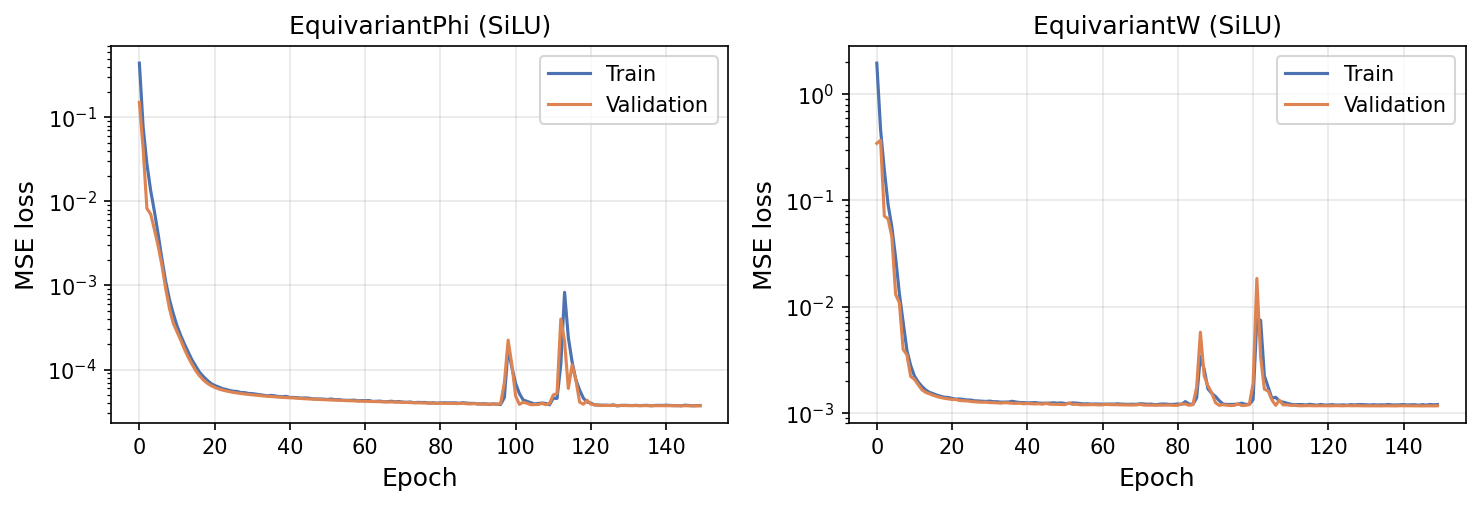

In [68]:
# === Figure: q4_training — Training curves (SiLU equivariant) ===

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

ax = axes[0]
ax.semilogy(hist_phi_smooth['train'], label='Train', color='#4C72B0')
ax.semilogy(hist_phi_smooth['val'], label='Validation', color='#DD8452')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('EquivariantPhi (SiLU)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(hist_W_smooth['train'], label='Train', color='#4C72B0')
ax.semilogy(hist_W_smooth['val'], label='Validation', color='#DD8452')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('EquivariantW (SiLU)')
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f'{FIGURE_DIR}/q4_training.png')
plt.show()

### Lagrangian implementation

We use PyTorch autograd for exact derivatives. Key detail: the network
outputs $W^\mu_a$ (upper index). We lower with $\eta_{\mu\nu}$ before
forming $G_{\mu\nu}^a$.

In [19]:
eta_diag = torch.tensor([1., -1., -1., -1.])
eta = torch.diag(eta_diag)

def compute_lagrangian(x, phi_model, W_model, m_phi=1.0, m_W=1.0):
    """
    Compute L = ∂_μΦ†∂^μΦ - m_Φ²Φ†Φ - (1/4)G_{μν}^a G^{μν a} + (1/2)m_W²W_μ^a W^{μa}
    
    Uses autograd for exact derivatives.
    Returns (L_total, L_phi, L_W) each of shape (N,).
    """
    x = x.clone().requires_grad_(True)
    N = x.shape[0]
    
    # === Scalar sector: Φ(x) ∈ R⁴ ===
    phi = phi_model(x)                         # (N, 4)
    dphi = torch.zeros(N, 4, 4)                # dphi[n, μ, i] = ∂_μ Φ_i
    for i in range(4):
        g = torch.autograd.grad(
            phi[:, i].sum(), x,
            create_graph=True, retain_graph=True)[0]
        dphi[:, :, i] = g
    
    # ∂_μΦ†∂^μΦ = η^{μμ} Σ_i (∂_μΦ_i)²  (η diagonal)
    kinetic_phi = torch.zeros(N)
    for mu in range(4):
        kinetic_phi += eta_diag[mu] * (dphi[:, mu, :] ** 2).sum(dim=1)
    
    mass_phi = (phi ** 2).sum(dim=1)           # Φ†Φ
    L_phi = kinetic_phi - m_phi**2 * mass_phi
    
    # === Vector sector: W^μ_a(x) ∈ R^{4×3} ===
    W_up = W_model(x).reshape(N, 4, 3)        # W^μ_a (upper index)
    
    # dW[n, ρ, μ, a] = ∂_ρ W^μ_a
    dW = torch.zeros(N, 4, 4, 3)
    for mu in range(4):
        for a in range(3):
            g = torch.autograd.grad(
                W_up[:, mu, a].sum(), x,
                create_graph=True, retain_graph=True)[0]
            dW[:, :, mu, a] = g
    
    # Lower W index: W_ν^a = η_{νσ} W^σ_a
    # G_{μν}^a = ∂_μ W_ν^a - ∂_ν W_μ^a
    #          = η_{νσ} dW[μ,σ,a] - η_{μσ} dW[ν,σ,a]
    G = torch.zeros(N, 4, 4, 3)
    for mu in range(4):
        for nu in range(4):
            for sig in range(4):
                G[:, mu, nu, :] += (
                    eta[nu, sig] * dW[:, mu, sig, :]
                  - eta[mu, sig] * dW[:, nu, sig, :]
                )
    
    # -1/4 G_{μν}^a G^{μν a} = -1/4 Σ_{μ,ν} η^{μμ}η^{νν} (G_{μν}^a)²
    G_sq = torch.zeros(N)
    for mu in range(4):
        for nu in range(4):
            G_sq += eta_diag[mu] * eta_diag[nu] * (
                G[:, mu, nu, :] ** 2).sum(dim=1)
    
    # 1/2 m² W_μ^a W^{μ a} = 1/2 m² η_{μμ} (W^μ_a)²
    W_sq = torch.zeros(N)
    for mu in range(4):
        W_sq += eta_diag[mu] * (W_up[:, mu, :] ** 2).sum(dim=1)
    
    L_W = -0.25 * G_sq + 0.5 * m_W**2 * W_sq
    
    return (
        (L_phi + L_W).detach(),
        L_phi.detach(),
        L_W.detach(),
    )

### Test 1 — Lorentz invariance: $\mathcal{L}(\Lambda x) = \mathcal{L}(x)$

Since the equivariant networks satisfy the symmetry exactly and all
Lorentz indices are properly contracted, $\mathcal{L}$ is a Lorentz
scalar by construction. We verify numerically.

In [20]:
def random_so3_rotation():
    angle = np.random.uniform(0, 2 * np.pi)
    axis = np.random.randn(3); axis /= np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    R3 = np.eye(3) + np.sin(angle)*K + (1-np.cos(angle))*(K@K)
    L = np.eye(4); L[1:,1:] = R3
    return L

def random_lorentz_boost(max_rapidity=0.5):
    rapidity = np.random.uniform(0, max_rapidity)
    d = np.random.randn(3); d /= np.linalg.norm(d)
    beta, gamma = np.tanh(rapidity), np.cosh(rapidity)
    L = np.eye(4)
    L[0,0] = gamma; L[0,1:] = -gamma*beta*d
    L[1:,0] = -gamma*beta*d
    L[1:,1:] += (gamma-1)*np.outer(d, d)
    return L

X_test = torch.tensor(
    np.random.uniform(-1.5, 1.5, (15, 4)).astype(np.float32))

L_base, Lp_base, Lw_base = compute_lagrangian(
    X_test, eq_phi_smooth, eq_W_smooth)

print('=== Lorentz invariance: L(Λx) = L(x) ===\n')
for label, gen in [('SO(3) rotation', random_so3_rotation),
                   ('Lorentz boost', random_lorentz_boost)]:
    errs = []
    for _ in range(10):
        Lambda = gen()
        Xr = torch.from_numpy(
            (Lambda @ X_test.numpy().T).T.astype(np.float32))
        Lt, _, _ = compute_lagrangian(Xr, eq_phi_smooth, eq_W_smooth)
        rel = np.abs(Lt.numpy() - L_base.numpy()) / (
            np.abs(L_base.numpy()) + 1e-6)
        errs.append(np.mean(rel))
    print(f'  {label}: mean rel error = {np.mean(errs):.2e}')

# Show individual comparisons
print('\nSample comparisons (boost):')
Lambda = random_lorentz_boost(0.5)
Xr = torch.from_numpy(
    (Lambda @ X_test[:5].numpy().T).T.astype(np.float32))
Lo, _, _ = compute_lagrangian(X_test[:5], eq_phi_smooth, eq_W_smooth)
Lt, _, _ = compute_lagrangian(Xr, eq_phi_smooth, eq_W_smooth)
print(f'{"L(x)":>12s}  {"L(Λx)":>12s}  {"rel diff":>10s}')
print('-' * 38)
for i in range(5):
    print(f'{Lo[i]:>12.6f}  {Lt[i]:>12.6f}  '
          f'{abs(Lt[i]-Lo[i])/(abs(Lo[i])+1e-6):>10.2e}')

=== Lorentz invariance: L(Λx) = L(x) ===



  SO(3) rotation: mean rel error = 1.72e-07
  Lorentz boost: mean rel error = 2.66e-07

Sample comparisons (boost):
        L(x)         L(Λx)    rel diff
--------------------------------------
   -0.828764     -0.828763    3.60e-07
   -1.196395     -1.196395    9.96e-08
   -0.020343     -0.020343    5.86e-06
   -0.649557     -0.649557    9.18e-08
   -0.561282     -0.561282    2.12e-07


Errors at float32 precision (~1e-7) confirm exact Lorentz invariance.

### Test 2 — SU(2) invariance

SU(2) is a global internal symmetry: $\Phi \to U\Phi$, $W^a \to R^{ab} W^b$.
The Lagrangian only involves $\Phi^\dagger \Phi$ (invariant by unitarity)
and $\delta_{ab}$ contractions on the adjoint index (invariant by orthogonality
of $R$). We verify that each invariant combination is preserved.

In [21]:
sigma = np.array([
    [[0, 1], [1, 0]],
    [[0, -1j], [1j, 0]],
    [[1, 0], [0, -1]],
], dtype=complex)

def random_su2():
    a = np.random.randn() + 1j*np.random.randn()
    b = np.random.randn() + 1j*np.random.randn()
    n = np.sqrt(abs(a)**2 + abs(b)**2)
    a, b = a/n, b/n
    return np.array([[a, -np.conj(b)], [b, np.conj(a)]])

def su2_to_adjoint(U):
    R = np.zeros((3, 3))
    Ud = U.conj().T
    for a in range(3):
        for b in range(3):
            R[a, b] = 0.5 * np.real(np.trace(sigma[a] @ U @ sigma[b] @ Ud))
    return R

print('=== SU(2) invariance of Lagrangian terms ===\n')

X_su2 = torch.tensor(
    np.random.uniform(-1.5, 1.5, (10, 4)).astype(np.float32))

with torch.no_grad():
    phi_vals = eq_phi_smooth(X_su2).numpy()
    W_vals = eq_W_smooth(X_su2).numpy().reshape(-1, 4, 3)

print(f'{"trial":>6s}  {"max |Δ(Φ†Φ)|":>14s}  {"max |Δ(W^a W^a)|":>18s}')
print('-' * 44)

for trial in range(5):
    U = random_su2()
    R = su2_to_adjoint(U)
    
    # Φ → UΦ: package as complex doublet
    doublet = np.stack([
        phi_vals[:, 0] + 1j*phi_vals[:, 1],
        phi_vals[:, 2] + 1j*phi_vals[:, 3],
    ], axis=1)
    doublet_U = (U @ doublet.T).T
    phi_sq_before = np.sum(phi_vals**2, axis=1)
    phi_sq_after = np.real(np.sum(np.conj(doublet_U)*doublet_U, axis=1))
    
    # W^a → R^{ab} W^b
    W_rot = np.einsum('ab,imb->ima', R, W_vals)
    W_sq_before = np.sum(W_vals**2, axis=(1, 2))
    W_sq_after = np.sum(W_rot**2, axis=(1, 2))
    
    print(f'{trial:>6d}  '
          f'{np.max(np.abs(phi_sq_after - phi_sq_before)):>14.2e}  '
          f'{np.max(np.abs(W_sq_after - W_sq_before)):>18.2e}')

=== SU(2) invariance of Lagrangian terms ===

 trial    max |Δ(Φ†Φ)|    max |Δ(W^a W^a)|
--------------------------------------------
     0        4.74e-08            2.32e-07
     1        4.74e-08            2.32e-07
     2        4.74e-08            2.32e-07
     3        4.74e-08            2.32e-07
     4        4.74e-08            2.32e-07


SU(2) invariants preserved to machine precision. The Lagrangian is SU(2)-invariant because it only involves $\Phi^\dagger\Phi$ (unitary invariant) and $\delta_{ab}$ contractions (adjoint invariant).

## Use of generative AI

Claude (Anthropic) was used to assist with code development and
report writing. All outputs were reviewed and tested by the author,
who takes full responsibility for the final submission.